In [ ]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_ollama import OllamaEmbeddings, ChatOllama
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv


False

In [23]:
docs = (
    PyPDFLoader(r"C:\Users\ay304\Downloads\Hypothetical Company Hr Docs Rag Dataset.pdf").load()
    + PyPDFLoader(r"C:\Users\ay304\Downloads\Nexora Hr Policy Handbook Separate.pdf").load()
)

In [24]:
chunks = RecursiveCharacterTextSplitter(
    chunk_size=600, chunk_overlap=150
).split_documents(docs)

In [25]:
embeddings = OllamaEmbeddings(model="nomic-embed-text")
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_kwargs={"k": 4})

In [26]:
llm = ChatOllama(model="Phi3", temperature=0)

In [27]:
# --------------------------------------------------
# Graph State
# --------------------------------------------------
class State(TypedDict):
    question: str
    need_retrieval: bool
    docs: List[Document]
    answer: str


In [36]:
rag_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using the provided context only.\n"
            "If the answer is not available in the context, say:\n"
            "'I could not find the answer in the provided documents.'"
        ),
        (
            "human",
            "Context:\n{context}\n\nQuestion:\n{question}"
        ),
    ]
)


def retrieve(state: State):
    return {
        "docs": retriever.invoke(state["question"])
    }


def generate_rag(state: State):

    context = "\n\n".join(
        doc.page_content for doc in state["docs"]
    )

    out = llm.invoke(
        rag_prompt.format_messages(
            context=context,
            question=state["question"]
        )
    )

    return {
        "answer": out.content
    }

In [29]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)


def generate_direct(state: State):
    out = llm.invoke(
        direct_generation_prompt.format_messages(
            question=state["question"]
        )
    )
    return {
        "answer": out.content
    }

In [30]:
def retrieve(state: State):
    return {"docs": retriever.invoke(state["question"])}

In [31]:
def route_after_decide(state: State) -> Literal["generate_direct", "retrieve"]:
    if state["need_retrieval"]:
        return "retrieve"
    return "generate_direct"

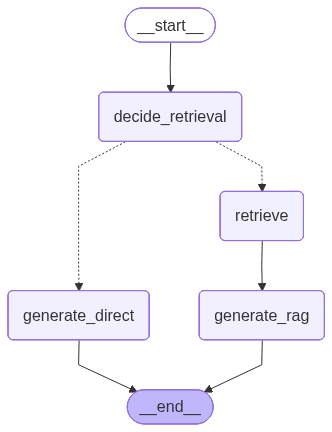

In [37]:
g = StateGraph(State)

# -----------------
# Nodes
# -----------------

g.add_node("decide_retrieval", decide_retrieval)

g.add_node("generate_direct", generate_direct)

g.add_node("retrieve", retrieve)

g.add_node("generate_rag", generate_rag)

# -----------------
# Edges
# -----------------

g.add_edge(START, "decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "generate_direct": "generate_direct",
        "retrieve": "retrieve",
    },
)

# Direct generation path
g.add_edge("generate_direct", END)

# RAG path
g.add_edge("retrieve", "generate_rag")

g.add_edge("generate_rag", END)

app = g.compile()

app


In [38]:
result = app.invoke(
    {
        "question": "Give me company detailes of Nexora Technologies Pvt. Ltd",
        "need_retrieval": False,
        "docs": [],
        "answer": "",
    }
)

print(result["answer"])

Nexora Technologies Pvt. Ltd was founded in the year 2018 and has its headquarters located in Bengaluru, Karnataka. The company employs over 540+ individuals and operates on a hybrid working model. Employees can be reached via email at @nexora-tech.com with office hours from 9:30 AM to 6:30 PM. They have set their probation period for new hires at six months, aligning themselves with core values such as Innovation First, Customer Obsession, Ownership Mindset, Data-Driven Decisions, Continuous Learning, and Ethical AI Development.


In [34]:
result['need_retrieval']

True

In [35]:
result['docs']

[Document(id='219cb73b-3352-44a9-9b77-b62063c62649', metadata={'producer': 'WeasyPrint 68.0', 'creator': 'ChatGPT', 'creationdate': '', 'title': 'Hypothetical Company Hr Docs Rag Dataset', 'author': 'ChatGPT Canvas', 'source': 'C:\\Users\\ay304\\Downloads\\Hypothetical Company Hr Docs Rag Dataset.pdf', 'total_pages': 15, 'page': 2, 'page_label': '3'}, page_content='Friday\nSmart casuals allowed.\nShorts and sleeveless clothing prohibited.\nProhibited Activities\nThe following activities may result in disciplinary action:\nSharing confidential client data.\nUnauthorized software installation.\nPhysical or verbal harassment.\nUse of company devices for illegal activities.\nMisrepresentation of company information.\nSocial Media Guidelines\nEmployees may not:\nShare confidential project screenshots.\nPublicly criticize clients.\nLeak internal communications.\nPost unreleased product details.\n3. ATTENDANCE & WORKING HOURS POLICY\nStandard Working Hours\nWork Type Timing'),
 Document(id='3